In [1]:
from SphereDetect import SphereDetect
# import numpy as np
# import pandas as pd


#### Testing the load data module
works for raw images and for cellprofiler output (OBS: a lot of data is missing)

In [2]:
# # Example usage: this works

# # image_path = '/home/jovyan/share/data/analyses/christa/SphereDetect/cp_output.parquet'
# image_path = '/mnt/external-images-pvc/spher-colo52-az/CellPainting_20241220clearedspheroidsBOMI_20241220_151510/AssayPlate_Corning_3830/'
# channel = 'SYTO'
# regex = r'([A-P]\d{1,2})_T0001F001L01A03Z(\d+)C03'
# z_info = 'Metadata_Plane'

# detector = SphereDetect()
# detector.load_data(image_path, regex, channel, z_info)


In [3]:
# df_backup = detector.data

# start = time.time()

# # Calculate the normalized variance for each image
# df_backup['normalized_variance'] = df_backup['image_path'].apply(lambda image: detector.calculate_normalized_variance(detector.read_image(image))) 

# end = time.time()
# length = end - start

# print("It took", length, "seconds!")


In [4]:
# df = df_backup.copy()

In [5]:
# df.head(1)

In [6]:
# # Caluclate the differential normalized variance
# df = (
#     df.sort_values(['Metadata_Well', 'Metadata_Z'])
#         .assign(delta_normalized_variance=lambda x: 
#             x.groupby('Metadata_Well')['normalized_variance'].diff())
# )

In [7]:
# def assign_plane(group, offset=-2):
    
#     idxmax = group['delta_normalized_variance'].idxmax()
#     offset_x = group.index.get_loc(idxmax) - offset # Offset by 1 to account for 0-based indexing
    
#     planes = (np.arange(len(group)) - offset_x)
#     planes = np.where(planes < 0, pd.NA, planes)# Replace negative plane values (i.e. rows before max) with NaN
    
#     group['Metadata_Z_calculated'] = pd.Series(planes, index=group.index, dtype='Int64')
#     return group

In [8]:
# # Assign the plane number to each image -> this does not work
# df = (
#     df.sort_values(['Metadata_Well', 'Metadata_Z'])
#     .groupby('Metadata_Well', group_keys=False)
#     .apply(lambda group: detector.assign_plane(group,offset=-2))
# )

In [9]:
# df

In [10]:
# #Identify the wells that meet the condition for plane 0
# wells_of_interest = df.loc[
#     (df['Metadata_Z_calculated'] == 0) & (df['normalized_variance'] > 250),
#         'Metadata_Well'].unique()

# filtered_df = df[df['Metadata_Well'].isin(wells_of_interest)]

In [11]:
# results = detector.detect_spheres(-2, 250)

In [ ]:
# Example usage: this also works

detector = SphereDetect()
detected_spheres = detector.run( 
        regex = r'([A-P]\d{1,2})_T0001F001L01A03Z(\d+)C03', #TODO: is this the best way to do this?
        channel = 'SYTO',
        image_path = '/mnt/external-images-pvc/spher-colo52-az/CellPainting_20241220clearedspheroidsBOMI_20241220_151510/AssayPlate_Corning_3830/', 
        # image_path = '/home/jovyan/share/data/analyses/christa/SphereDetect/cp_output.parquet',
        z_info = 'Metadata_Plane',
        offset = -2,
        fmin = 250,
        visualize = True,
)

# print(detected_spheres)


In [13]:
detector.results

,image_path,Metadata_Well,Metadata_Z,normalized_variance,delta_normalized_variance,Metadata_Z_calculated
13907,/mnt/external-images-pvc/spher-colo52-az/CellP...,B02,1,175.678265,NaN,<NA>
13931,/mnt/external-images-pvc/spher-colo52-az/CellP...,B02,2,178.286679,2.608414,<NA>
18988,/mnt/external-images-pvc/spher-colo52-az/CellP...,B02,3,182.524012,4.237333,<NA>
11471,/mnt/external-images-pvc/spher-colo52-az/CellP...,B02,4,186.251370,3.727358,<NA>
10849,/mnt/external-images-pvc/spher-colo52-az/CellP...,B02,5,188.243579,1.992208,<NA>
...,...,...,...,...,...,...
20487,/mnt/external-images-pvc/spher-colo52-az/CellP...,O21,67,123.392465,-3.119061,46
18653,/mnt/external-images-pvc/spher-colo52-az/CellP...,O21,68,120.182305,-3.210160,47
17528,/mnt/external-images-pvc/spher-colo52-az/CellP...,O21,69,116.321962,-3.860343,48
5885,/mnt/external-images-pvc/spher-colo52-az/CellP...,O21,70,113.877122,-2.444841,49


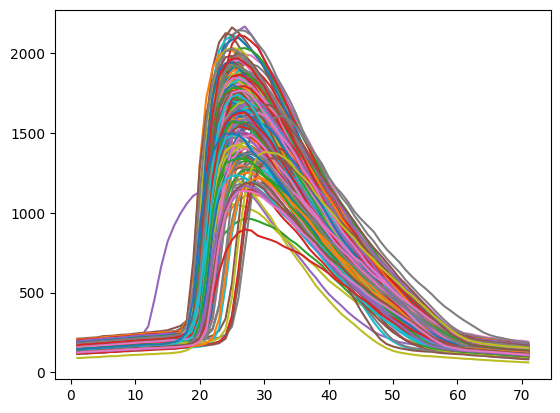

In [14]:
import matplotlib.pyplot as plt

## For inspection only

df_plot = detector.results

# Group df by Metadata_Well and sort by Metadata_Z
df_plot = df_plot.sort_values(by='Metadata_Z')
df_grouped = df_plot.groupby('Metadata_Well')

# Then plot the normalized variance across Z for each well
fig, ax = plt.subplots()
for name, group in df_grouped:
    ax.plot(group['Metadata_Z'], group['normalized_variance'], label=name)